# Maestría en Ciencias de la Computación - Visión Computacional

Fecha de entrega: jueves 16 de abril de 2026

Alumno: Jesús Virgilio Ayala Gaspar 

Profesor: Arturo Espinosa Romero

---

## Proyecto - Detección de Objetos

El objetivo de este ejercicio es hace un programa que lea imágenes de un archivo de video y que de manera automática identifique los objetos cuando estos pasen por en centro de la imagen.

El video contiene muestras de varias formas que transitan de derecha a izquierda, elegidas de un conjunto de 17 posibilidades. Utilizando las técnicas de segmentación por umbralización, detección de contornos y momentos geométricos que hemos visto en clase, implemente un programa que analize el video e identifique cada una de las formas por su número, esto es, la salida del programa debe ser un archivo de texto que contenga la lista de  correcta de  formas detectadas.

Además del programa se deberá entregar un reporte en donde se describa el procedimiento que siguieron y se reporten y comenten los resultados.

---

## Procedimiento

El procedimiento clásico para llevar a cabo un programa de detección de objetos en un video contiene 7 pasos fundamentales:

- 1. Pruebas de segmentación 
- 2. Extracción de contornos 
- 3. Cálculo de descriptores 
- 4. Construcción de base de datos 
- 5. Clasificador 
- 6. Procesamiento de video 
- 7. Resultados y guardado

---

### 1. Pruebas de segmentación

El primer paso consiste en la forma de segmentación que utiliza OpenCV


En la carpeta proporcionada "deteccionObjetos" contamos con 17 imágenes nombradas "Forma_xx.png" en donde cada imágen contiene una figura de color negro con un fondo blanco

Nuestro objetivo para cada imágen es que la figura quede separada del fondo y cumpla las siguientes métricas:

- Fondo completamente negro o blanco
- Figura completamente blanca o negra
- Sin ruido
- Sin huecos
- Sin bordes rotos

A continuación, se muestra el procedimiento de la implementación de segmentación de figuras en imágenes estáticas:

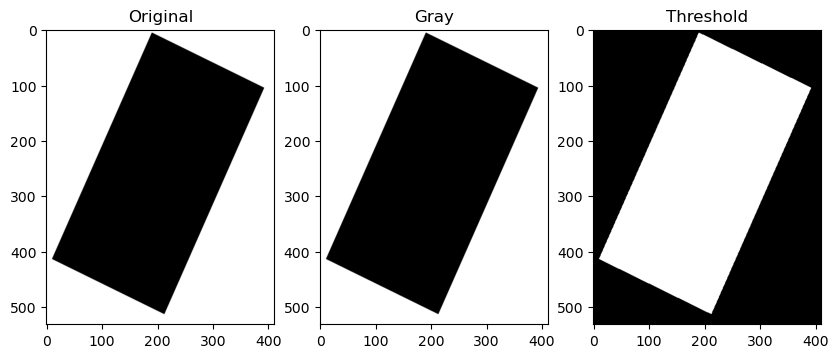

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargamos la imágen
img = cv2.imread("deteccionObjetos/Forma_00.png")

# Convertir a escala de grises
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Aplicar umbral
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

# Mostrar resultados
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(1,3,2)
plt.title("Gray")
plt.imshow(gray, cmap='gray')

plt.subplot(1,3,3)
plt.title("Threshold")
plt.imshow(thresh, cmap='gray')

plt.show()

Los pasos son los siguientes:

- 1. Cargamos la imágen a la variable img mediante OpenCV
- 2. Cambiamos la imágen de RGB a Escala de Grises para la consistencia en el uso de funciones (las operaciones siguientes requieren un único canal de color)
- 3. Convertimos la imágen de Escala de Grises a Binaria e invertimos los colores para el futuro uso de funciones (la detección de contornos requiere imágenes binarias para evitar ruido, sombras y bordes falsos)
- 4. Por último se hace muestra la imágen siendo procesada en cada etapa del proceso
---

### 2. Extracción de contornos

El contorno de una imágen se puede definir como una lista de puntos que describen el borde de un objeto.

Para idenficar los contornos utilizamos la función findContours implementada en OpenCV, a la cual le pasamos como parámetro la variable "thresh" obtenida en el paso anterior:

In [2]:
contornos, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

- La bandera RETR_EXTERNAL devuelve los contornos externos para evitar ruido y agujeros
- La bandera CHAIN_APPROX_SIMPLE comprime puntos redundantes

A continuación se muestran las formas 00, 03 y 06 con sus contornos remarcados

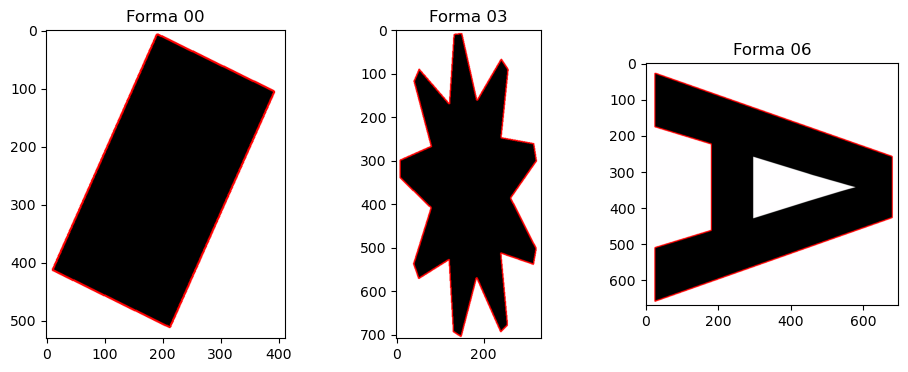

In [3]:
img03 = cv2.imread("deteccionObjetos/Forma_03.png")
gray03 = cv2.cvtColor(img03, cv2.COLOR_BGR2GRAY)
_, thresh03 = cv2.threshold(gray03, 127, 255, cv2.THRESH_BINARY_INV)
contornos03, _ = cv2.findContours(thresh03, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img06 = cv2.imread("deteccionObjetos/Forma_06.png")
gray06 = cv2.cvtColor(img06, cv2.COLOR_BGR2GRAY)
_, thresh06 = cv2.threshold(gray06, 127, 255, cv2.THRESH_BINARY_INV)
contornos06, _ = cv2.findContours(thresh06, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

Forma00 = img.copy()
Forma03 = img03.copy()
Forma06 = img06.copy()

plt.figure(figsize=(15,4))

plt.subplot(1,4,1)
cv2.drawContours(Forma00, contornos, -1, (0,0,255), 2)
plt.imshow(cv2.cvtColor(Forma00, cv2.COLOR_BGR2RGB))
plt.title("Forma 00")

plt.subplot(1,4,2)
cv2.drawContours(Forma03, contornos03, -1, (0,0,255), 2)
plt.imshow(cv2.cvtColor(Forma03, cv2.COLOR_BGR2RGB))
plt.title("Forma 03")

plt.subplot(1,4,3)
cv2.drawContours(Forma06, contornos06, -1, (0,0,255), 2)
plt.imshow(cv2.cvtColor(Forma06, cv2.COLOR_BGR2RGB))
plt.title("Forma 06")


plt.show()


Es importante notar que en las Formas 3 y 6 únicamente resaltan los contornos externos sin tomar en cuenta los huecos internos de la figura 

Como último paso agregamos una variable para filtrar los múltiples contornos que puede haber en una imágen y le asignamos la figura que ocupa más área que representará la figura principal 

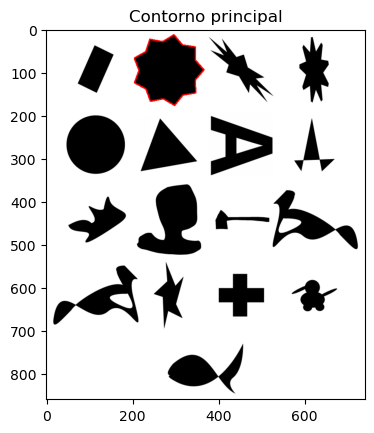

In [4]:
img = cv2.imread("deteccionObjetos/Formas.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

cnt = max(contornos, key=cv2.contourArea)

img_contorno_final = img.copy()

cv2.drawContours(img_contorno_final, [cnt], -1, (0,0,255), 2)

plt.imshow(cv2.cvtColor(img_contorno_final, cv2.COLOR_BGR2RGB))
plt.title("Contorno principal")
plt.show()

---

### 3. Cálculo de descriptores (Momentos de Hu)

El objetivo de este apartado es convertir un contorno en un vector numérico que represente la forma y sea independiente de:

- Posición
- Tamaño
- Rotación

Ese vector son los Momentos de Hu y se obtiene mediante el siguiente procedimiento:

1. Utilizamos la función moments(cnt) y le pasamos como parámetro el contorno principal de la imágen:

In [5]:
img = cv2.imread("deteccionObjetos/Forma_00.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

cnt = max(contornos, key=cv2.contourArea)

momentos = cv2.moments(cnt)

print(momentos)

{'m00': 99912.5, 'm10': 20139540.833333332, 'm01': 25906447.166666664, 'm20': 4667718071.75, 'm11': 4779333422.791666, 'm02': 8177507109.083333, 'm30': 1186053517924.45, 'm21': 1031836622475.1833, 'm12': 1418793497202.3167, 'm03': 2877583209312.5503, 'mu20': 608154904.2033906, 'mu11': -442675340.472949, 'mu02': 1460189408.1020622, 'mu30': -476889.9050292969, 'mu21': -589324.7133178711, 'mu12': 2578164.557434082, 'mu03': -2632150.2602539062, 'nu20': 0.06092205737729915, 'nu11': -0.04434510402762297, 'nu02': 0.1462748097355923, 'nu30': -1.51136222859413e-07, 'nu21': -1.8676912693947188e-07, 'nu12': 8.17073393693791e-07, 'nu03': -8.341825736670969e-07}


Esto genera los momentos, que representan la información cruda de la imágen 

- m00 → área
- m10, m01 → centroide
- m20, m02 → distribución
- ...

2. Utilizamos la función HuMoments(momentos) y le pasamos como parámetro los momentos obtenidos

In [6]:
huMomentos = cv2.HuMoments(momentos)

print(huMomentos)

[[ 2.07196867e-01]
 [ 1.51510453e-02]
 [ 6.84726647e-12]
 [ 1.48581469e-12]
 [ 4.57006672e-24]
 [ 1.71714323e-13]
 [-1.25481620e-24]]


Esto genera 7 valores numéricos que describen la forma, sin embargo, son valores muy pequeños y no es posible trabajar directamente con ellos por lo que es necesario adaptarlos para poder trabajar con ellos.

3. Utilizamos una transformación logarítmica para trabajar con los Momentos de Hu

In [7]:
huMomentos = cv2.HuMoments(momentos).flatten()

for i in range(len(huMomentos)):
    huMomentos[i] = -np.sign(huMomentos[i]) * np.log10(abs(huMomentos[i]) + 1e-10)
    
print(huMomentos)

[  0.68361682   1.8195574    9.97123658   9.99359466  10.
   9.99925489 -10.        ]


Con esto hemos obtenido los momentos de hu y transformado en valores posibles de usar en la detección de objetos.

4. Definimos la función que utilizaremos para detectar objetos en el video mediante sus respectivos Momentos de Hu

In [8]:
def obtenerHu(cnt):
    M = cv2.moments(cnt)
    hu = cv2.HuMoments(M).flatten()

    # transformación log
    for i in range(len(hu)):
        hu[i] = -np.sign(hu[i]) * np.log10(abs(hu[i]) + 1e-10)

    return hu

# IMPORTANTE

5. Normalizar los Momentos de Hu

In [9]:
def normalizarHu(hu):
    hu = np.abs(hu)
    hu = np.where(hu == 0, 1e-10, hu)
    return -np.sign(hu) * np.log10(hu)

---

### 4. Construcción de base de datos

El objetivo del siguiente apartado es crear una estructura que asigne el ID de una figura con sus Momentos de Hu para poder clasificar e identificar las 17 formas proporcionadas.

Para ello utilizaremos un ciclo for para recorrer todas las imágenes y uniremos las etapas anteriores para crear la base de datos:

In [10]:
dataBase = {}

for i in range(17):
    
    #Leer Imágen
    ruta = f"deteccionObjetos/Forma_{i:02d}.png"
    img = cv2.imread(ruta)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

    #Obtener Contorno
    contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnt = max(contornos, key=cv2.contourArea)
    
    #Obtener Momentos
    hu = obtenerHu(cnt)
    hu = normalizarHu(hu)
    
    #Guardar Momentos
    dataBase[i] = hu

Los contenidos de la base de datos son los siguientes:

In [11]:
for k in range(len(dataBase)):
    print(k)
    print(dataBase[k])

0
[ 0.16518726 -0.25996576 -0.99874902 -0.99972173 -1.         -0.99996764
 -1.        ]
1
[ 0.10152483 -0.97023529 -0.98276447 -0.99881834 -1.         -0.99999998
 -1.        ]
2
[ 0.35129201 -0.01164152 -0.9189638  -0.94535802 -1.         -0.96715587
 -1.        ]
3
[ 0.20704201 -0.20298632 -0.92597943 -0.95745513 -1.         -0.98685755
 -1.        ]
4
[ 0.0978997  -0.98361585 -0.98600871 -1.         -1.         -1.
 -1.        ]
5
[ 0.14536714 -0.66429651 -0.36933639 -0.78766266 -0.99665409 -0.94207981
 -0.99387378]
6
[ 0.18837805 -0.4423299  -0.34299974 -0.56202343 -0.81775851 -0.70176266
 -0.93445858]
7
[ 0.39894251 -0.19221472 -0.07987955 -0.47945631 -0.77623194 -0.63481787
 -0.71008603]
8
[ 0.2052612  -0.23925521 -0.51046444 -0.54559494 -0.84445269 -0.66808501
 -0.85131912]
9
[ 0.19118176 -0.30905289 -0.46026529 -0.60360902 -0.8767437  -0.75686487
 -0.88941131]
10
[ 1.26071379  0.70213458  0.46483785  0.31021837  0.04294306  0.22867926
 -0.40900693]
11
[ 0.37280544 -0.06783425 

---

### 5. Clasificador

Esta es la segunda pieza clave del proyecto, en este apartado recibiremos un vector númerico de 7 valores y compararemos con la base de datos para encontrar la figura más parecida acorde a los Momentos de Hu

Para ello crearemos una función llamda clasificar() que recibirá como parámetros los Momentos de Hu que buscamos comparar y la base de datos con los Momentos de las 17 figuras:

In [12]:
def clasificar(hu, dataBase):
    mejor_id = -1
    mejor_dist = float("inf")

    for id_fig, hu_db in dataBase.items():
        dist = np.linalg.norm(hu - hu_db)

        if dist < mejor_dist:
            mejor_dist = dist
            mejor_id = id_fig

    return mejor_id

Variables de la función

- La variable mejor_id que regresará la mejor coincidencia de figura respecto a la base de datos
- La variable mejor_dist medirá que tan diferentes son ambas formas

Variables del ciclo for 

- id_fig identifica el número de figura que está comparando
- hu_db refiere a los momentos de Hu del id correspondiente

Dentro del ciclo for

- Mediante la función np.linalg.norm(hu - hu_db) comparamos la distancia entre dos vectores y la almacenamos en la variable dist
- Se compara dist con con la previa mejor distancia y en caso de ser menor se actualizan los resultados
- Por último regresa el ID de la figura más parecida

A continuación, una muestra de su funcionamiento:

In [13]:
for i in range(17):
    
    #Leer Imágen
    ruta = f"deteccionObjetos/Forma_{i:02d}.png"
    img = cv2.imread(ruta)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

    #Obtener Momentos
    contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnt = max(contornos, key=cv2.contourArea)
    hu = obtenerHu(cnt)
    hu = normalizarHu(hu)
    
    #Comparar
    prediccion = clasificar(hu, dataBase)
    print("La figura más parecida es la ", prediccion)

La figura más parecida es la  0
La figura más parecida es la  1
La figura más parecida es la  2
La figura más parecida es la  3
La figura más parecida es la  4
La figura más parecida es la  5
La figura más parecida es la  6
La figura más parecida es la  7
La figura más parecida es la  8
La figura más parecida es la  9
La figura más parecida es la  10
La figura más parecida es la  11
La figura más parecida es la  12
La figura más parecida es la  13
La figura más parecida es la  14
La figura más parecida es la  15
La figura más parecida es la  16


---

### 6. Procesamiento de video

Con todo lo anterior preparado solo queda aplicarlo en el video

El objetivo de este apartado es procesar el video fotograma por fotograma, identificar las figuras, clasificarlas e imprimir su mejor coincidencia respecto a la base de datos ya construida.

Para ello seguiremos el siguiente procedimiento:

In [14]:
camera = cv2.VideoCapture("deteccionObjetos/video.mpg")

frameCount = 0
ultimoDetectado = -100
huBuffer = []
resultados = []

- Leemos el video mediante OpenCV 
- Creamos una variable para llevar la cuenta de los frames desde el inicio del video
- Guardamos el último frame donde se detectó una figura para no repetir 
- Creamos una variable para almacenar los resultados

Una vez preparado el escenario creamos un ciclo while para avanzar frame por frame el video

Variables del ciclo While

- ret - detecta si hay un frame en el video y rompe el ciclo si no lo hay
- frame - almacena el fotograma actual y avanza al siguiente en cada iteración del ciclo

Dentro del ciclo While

- Obtenemos el frame mediante camera.read()
- Procesamos el Fotograma
- Obtenemos los Contornos
- Calculamos el área de los contornos para filtrarlos por un tamaño mayor a 1500 pixeles (de esta forma se evita el ruido)
- Obtenemos el centro del video y lo usamos para dibujar una línea vertical que ayudará a identificar las figuras

Dentro del ciclo For

- Iteramos sobre todos los contornos del fotograma usando la variable cnt
- Obtenemos los momentos de todas las figuras del fotograma
- Identificamos el centroide de las figuras
- Dibujamos los contornos y centro de las figuras
- Comprobamos si la figura está en el centro y evitamos repeticiones

Si todas las condiciones se cumplen clasificamos la figura respecto a la base de datos y guardamos el resultado


In [15]:
while True:
    ret, frame = camera.read()
    if not ret:
        break

    frameCount += 1

    #Procesar Fotograma
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    #Procesar Contorno
    contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contornosFiltrados = [c for c in contornos if cv2.contourArea(c) > 1500]

    # Dibujar línea central
    centroX = frame.shape[1] // 2
    cv2.line(frame, (centroX, 0), (centroX, frame.shape[0]), (0,255,0), 2)
    
    for cnt in contornosFiltrados:
        
        #Obtener Momentos
        M = cv2.moments(cnt)
        if M["m00"] == 0:
            continue
        
        #Calcular centroide
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        cx_anterior = cx

        # Dibujar
        cv2.drawContours(frame, [cnt], -1, (255, 0, 0), 2)
        cv2.circle(frame, (cx, cy), 5, (0,0,255), -1)

        # Detección en el centro
        if abs(cx - centroX) < 15:

            # evitar múltiples detecciones
            if frameCount - ultimoDetectado > 1:

                try:
                    #Clasificamos
                    hu = obtenerHu(cnt)
                    hu = normalizarHu(hu)
                    
                    #Obtiene un promedio de los Momentos de Hu 
                    huBuffer.append(hu)
                    
                    if len(huBuffer) >= 5:
                        hu_prom = np.mean(huBuffer, axis=0)

                        id_fig = clasificar(hu_prom, dataBase)

                        resultados.append(id_fig)
                        print("Detectado: ", id_fig)

                        huBuffer = []  # reset
                    
                    '''
                    id_fig = clasificar(hu, dataBase)

                    resultados.append(id_fig)
                    print("Detectado: ", id_fig)
                    '''
                    
                    
                    ultimoDetectado = frameCount

                except:
                    pass

    #Mostrar el video
    cv2.imshow("Video", frame)

    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

camera.release()
cv2.destroyAllWindows()

QSocketNotifier: Can only be used with threads started with QThread


Detectado:  11
Detectado:  7
Detectado:  7
Detectado:  6
Detectado:  16
Detectado:  11
Detectado:  14
Detectado:  11
Detectado:  7
Detectado:  2
Detectado:  6
Detectado:  9
Detectado:  5
Detectado:  3
Detectado:  3
Detectado:  8
Detectado:  0
Detectado:  14
Detectado:  2
Detectado:  8
Detectado:  6
Detectado:  16
Detectado:  9
Detectado:  8
Detectado:  13
Detectado:  7
Detectado:  3
Detectado:  11
Detectado:  7
Detectado:  9
Detectado:  11
Detectado:  5
Detectado:  11
Detectado:  9
Detectado:  14
Detectado:  6
Detectado:  8
Detectado:  15
Detectado:  16
Detectado:  5
Detectado:  3
Detectado:  9
Detectado:  14
Detectado:  3
Detectado:  3
Detectado:  5
Detectado:  2
Detectado:  15
Detectado:  5
Detectado:  5


---


### 7. Resultados y guardado

Para finalizar guardamos la salida en un archivo de texto

In [16]:
with open("salida.txt", "w") as f:
    for r in resultados:
        f.write(f"figId = {r}\n")